## IMPORT LIBRARIES

In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import joblib

from sklearn.preprocessing import OneHotEncoder,TargetEncoder,StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso 
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')

In [3]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

## LOAD DATASET

In [4]:
df = pd.read_csv('indian_used_car_noisy_2500.csv')

## EDA

In [5]:
df.head()

,brand,model,year,fuel_type,transmission,km_driven,owner_type,city,mileage,engine_cc,condition_rating,original_price,listed_price,estimated_final_price,days_to_sell,bargain_percent,car_age,depreciation_amount,resale_value_percent,demand_score,brand_popularity_score,price_per_km,premium_car
0,Maruti,Baleno,2024,Diesel,Automatic,14345,Second,Bhopal,20.0,1199.0,10,1133417,998993,819174,17.0,18,1,143468,88.14,9.19,10,69.64,0
1,Hyundai,Creta,2023,Petrol,Automatic,15461,First,Kolkata,21.0,1493.0,8,1573516,1257081,1093660,42.0,13,2,358330,79.89,9.13,10,81.31,0
2,Hyundai,Alcazar,2024,Petrol,Manual,17868,Third,Pune,20.0,1999.0,10,2215825,1929318,1794265,39.0,7,1,260541,87.07,9.02,10,107.98,0
3,Hyundai,Creta,2023,Petrol,Manual,21002,First,Bangalore,16.0,1493.0,10,1407825,1181587,1110691,26.0,6,2,253206,83.93,10.00,10,56.26,0
4,Tata,Tiago,2020,Petrol,Manual,59742,Second,Chandigarh,14.0,1199.0,8,671505,386921,375313,22.0,3,5,301973,57.62,7.18,8,6.48,0


In [6]:
df.tail()

,brand,model,year,fuel_type,transmission,km_driven,owner_type,city,mileage,engine_cc,condition_rating,original_price,listed_price,estimated_final_price,days_to_sell,bargain_percent,car_age,depreciation_amount,resale_value_percent,demand_score,brand_popularity_score,price_per_km,premium_car
2495,MG,ZS EV,2016,Diesel,Manual,159170,Third,Kolkata,28.0,0.0,5,2619844,535496,428396,53.0,20,9,2099134,20.44,4.32,6,3.36,1
2496,Hyundai,Verna,2025,CNG,Manual,500,First,Delhi,27.0,1497.0,10,1593709,1514023,1408041,NaN,7,0,0,95.00,8.46,8,3028.05,0
2497,Kia,EV6,2021,Petrol,Automatic,69561,Second,Lucknow,15.0,0.0,6,7158720,4449860,4227367,35.0,5,4,2537657,62.16,6.87,7,63.97,1
2498,Renault,Kiger,2019,Petrol,Manual,110155,Second,Surat,16.0,999.0,7,758407,436159,396904,47.0,9,6,333785,57.51,8.12,6,3.96,0
2499,Toyota,Glanza,2025,Diesel,Manual,500,First,Surat,21.0,1197.0,10,995487,945712,888969,15.0,6,0,0,95.00,10.00,9,1891.42,0


In [7]:
df.shape

(2500, 23)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   brand                   2500 non-null   object 
 1   model                   2500 non-null   object 
 2   year                    2500 non-null   int64  
 3   fuel_type               2500 non-null   object 
 4   transmission            2500 non-null   object 
 5   km_driven               2500 non-null   int64  
 6   owner_type              2500 non-null   object 
 7   city                    2500 non-null   object 
 8   mileage                 2449 non-null   float64
 9   engine_cc               2477 non-null   float64
 10  condition_rating        2500 non-null   int64  
 11  original_price          2500 non-null   int64  
 12  listed_price            2500 non-null   int64  
 13  estimated_final_price   2500 non-null   int64  
 14  days_to_sell            2449 non-null   

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,2500.0,2.020756e+03,3.507333e+00,2010.00,2019.00,2022.000,2.024000e+03,2025.00
km_driven,2500.0,7.168001e+04,8.677643e+04,17.00,20931.50,53692.500,1.003170e+05,2275020.00
mileage,2449.0,2.015149e+01,1.248330e+01,11.00,16.00,20.000,2.200000e+01,376.00
engine_cc,2477.0,1.392204e+03,5.304987e+02,0.00,1197.00,1462.000,1.498000e+03,2755.00
condition_rating,2500.0,7.214400e+00,2.212146e+00,1.00,6.00,7.000,9.000000e+00,10.00
original_price,2500.0,1.789344e+06,1.512205e+06,311656.00,983294.75,1251693.500,1.824158e+06,9982350.00
listed_price,2500.0,1.212425e+06,1.229301e+06,16500.00,541216.00,879515.500,1.347035e+06,9483232.00
estimated_final_price,2500.0,1.079501e+06,1.092303e+06,40203.00,483523.25,787397.500,1.202343e+06,8322831.00
days_to_sell,2449.0,3.683912e+01,1.310809e+01,6.00,28.00,36.000,4.500000e+01,80.00
bargain_percent,2500.0,1.097560e+01,5.219837e+00,2.00,7.00,11.000,1.500000e+01,24.00


### DISTRIBUTION OF COLUMNS

#### BRAND

In [10]:
df['brand'].unique()

array(['Maruti', 'Hyundai', 'Tata', 'Toyota', 'Kia', 'Nissan', 'Skoda',
       'Renault', 'Mahindra', 'MG', 'Ford', 'Honda', 'Volkswagen'],
      dtype=object)

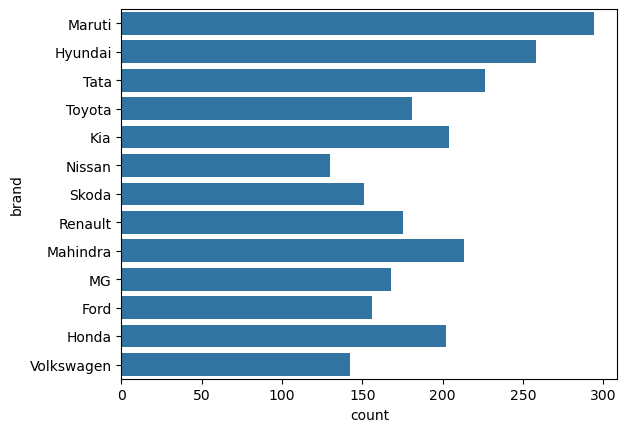

In [11]:
sns.countplot(data=df,y='brand')
plt.show()

#### MODEL

In [12]:
df['model'].unique()

array(['Baleno', 'Creta', 'Alcazar', 'Tiago', 'Urban Cruiser', 'EV6',
       'i20', 'Seltos', 'Kicks', 'Kushaq', 'Grand i10', 'Swift', 'Kiger',
       'XUV300', 'Glanza', 'Terrano', 'Tigor', 'Astor', 'Aura', 'Verna',
       'Figo', 'Tucson', 'Nexon', 'Aspire', 'Duster', 'Thar', 'Innova',
       'Harrier', 'Slavia', 'EcoSport', 'Amaze', 'Endeavour', 'Vento',
       'Camry', 'Punch', 'Taigun', 'Jazz', 'Ertiga', 'XUV700', 'WagonR',
       'Altroz', 'ZS EV', 'Polo', 'Octavia', 'Kodiaq', 'Dzire', 'Ciaz',
       'Fortuner', 'Safari', 'Kwid', 'Brezza', 'Magnite', 'Triber',
       'Carens', 'Virtus', 'WR-V', 'Elevate', 'Bolero', 'Venue', 'HR-V',
       'Hector', 'Gloster', 'Sonet', 'Scorpio', 'Alto', 'City', 'XUV400'],
      dtype=object)

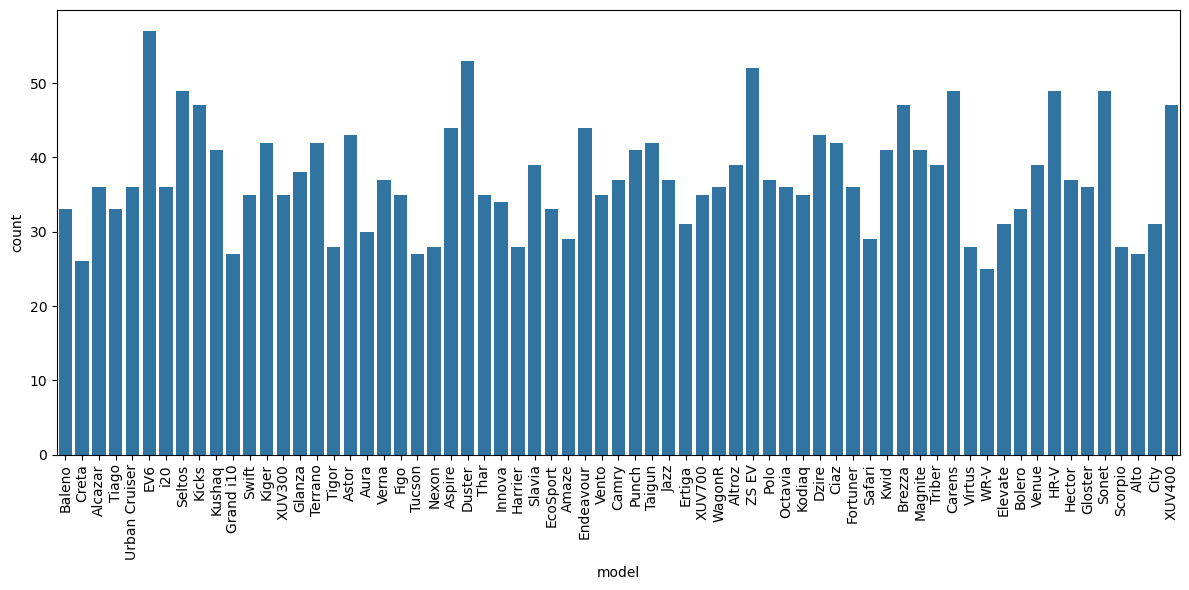

In [13]:
plt.figure(figsize=(12,6))
sns.countplot(data=df,x='model')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

#### YEAR

In [14]:
df['year'].unique()

array([2024, 2023, 2020, 2016, 2017, 2018, 2025, 2010, 2022, 2021, 2019,
       2015, 2012, 2013, 2014, 2011])

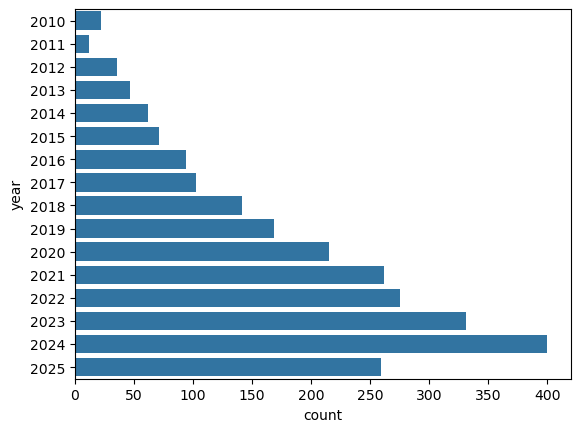

In [15]:
sns.countplot(data=df,y='year')
plt.show()

#### FUEL TYPE

In [16]:
df['fuel_type'].unique() 

array(['Diesel', 'Petrol', 'CNG', 'Electric', 'DIESEL', 'PETROL'],
      dtype=object)

#### TRANSMISSION

In [17]:
df['transmission'].unique()

array(['Automatic', 'Manual'], dtype=object)

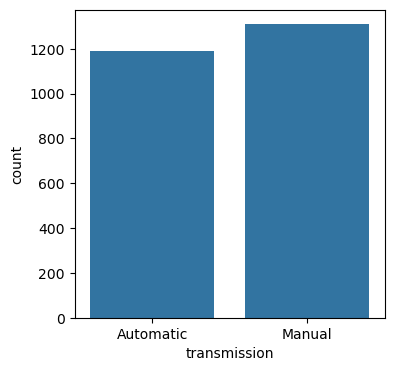

In [18]:
plt.figure(figsize=(4,4))
sns.countplot(data=df,x='transmission')
plt.show()

#### KM DRIVEN

In [19]:
df['km_driven'].unique()

array([ 14345,  15461,  17868, ..., 159170,  69561, 110155])

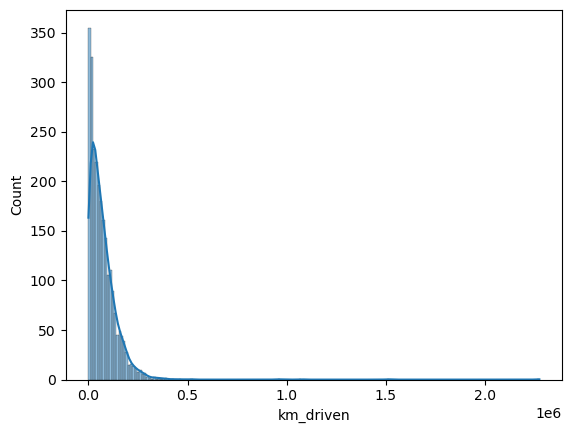

In [20]:
sns.histplot(data=df,x='km_driven',kde=True)
plt.show()

#### OWNER TYPE

In [21]:
df['owner_type'].unique()

array(['Second', 'First', 'Third', 'Fourth'], dtype=object)

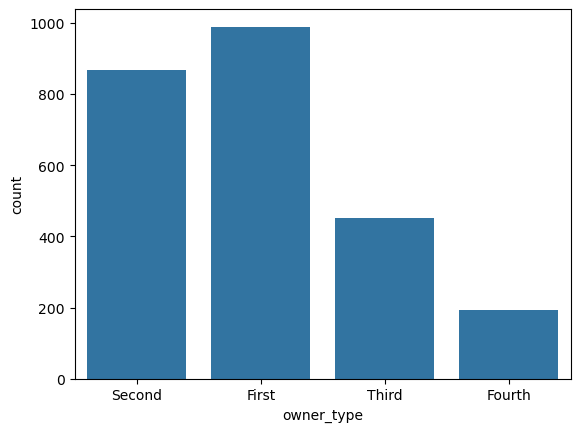

In [22]:
sns.countplot(data=df,x='owner_type')
plt.show()

#### CITY

In [23]:
df['city'].unique() 

array(['Bhopal', 'Kolkata', 'Pune', 'Bangalore', 'Chandigarh',
       'Ahmedabad', 'Hyderabad', 'Coimbatore', 'Mumbai', 'Jaipur',
       'Lucknow', 'Delhi', 'Nagpur', 'Surat', 'Chennai', 'bangalore',
       'hyderabad', 'chennai', 'lucknow', 'coimbatore', 'chandigarh',
       'mumbai', 'kolkata', 'delhi', 'surat', 'nagpur', 'jaipur'],
      dtype=object)

#### MILEAGE

In [24]:
df['mileage'].unique()

array([ 20.,  21.,  16.,  14.,  15.,  22.,  18.,  25.,  17.,  24., 243.,
        19.,  27.,  26.,  nan,  30.,  28.,  23.,  13., 376.,  29.,  12.,
       342., 260.,  11.])

#### ENGINE CC

In [25]:
df['engine_cc'].unique() 

array([1199., 1493., 1999., 1462.,    0., 1197., 1497., 1461., 1498.,
        999., 1499., 1495., 1196., 1194., 1998., 1496., 2184., 2393.,
       1956., 1996., 1598., 2487., 1491., 1982., 1984.,   nan, 2755.,
        799., 1500., 1200., 1597., 1001., 1201., 1463.,  796., 2186.,
       2182., 1596.,  997., 1492., 1195., 1983., 1460., 1198., 1459.,
        797., 1464., 1995.,  998., 1997., 1193., 2183., 1958., 1192.,
       1986., 2754.,  795., 2001., 2489., 1600., 1954., 2753.])

#### CONDITION RATING

In [26]:
df['condition_rating'].unique()

array([10,  8,  6,  7,  4,  5,  2,  9,  3,  1])

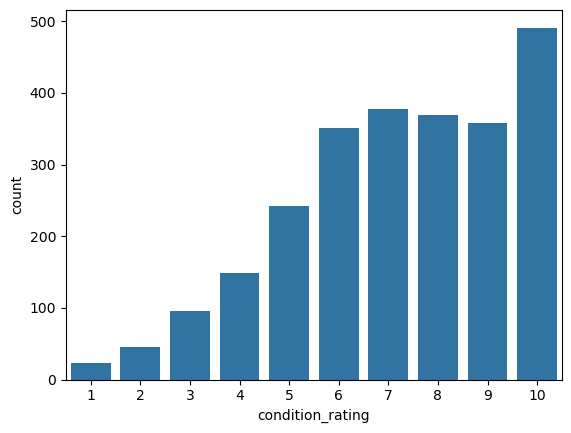

In [27]:
sns.countplot(data=df,x='condition_rating')
plt.show()

#### ORIGINAL PRICE

In [28]:
df['original_price'].unique()

array([1133417, 1573516, 2215825, ..., 7158720,  758407,  995487])

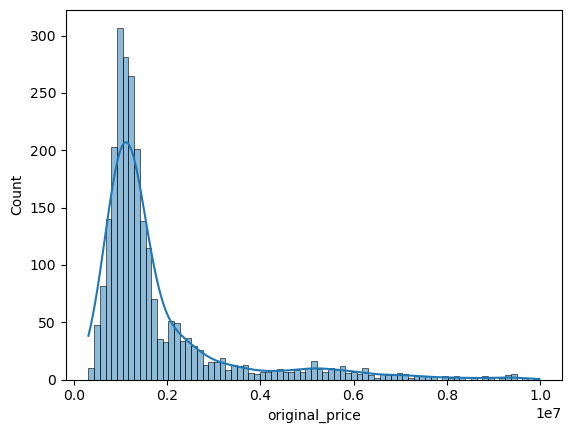

In [29]:
sns.histplot(data=df,x='original_price',kde=True)
plt.show()

#### LISTED PRICE

In [30]:
df['listed_price'].unique()

array([ 998993, 1257081, 1929318, ..., 4449860,  436159,  945712])

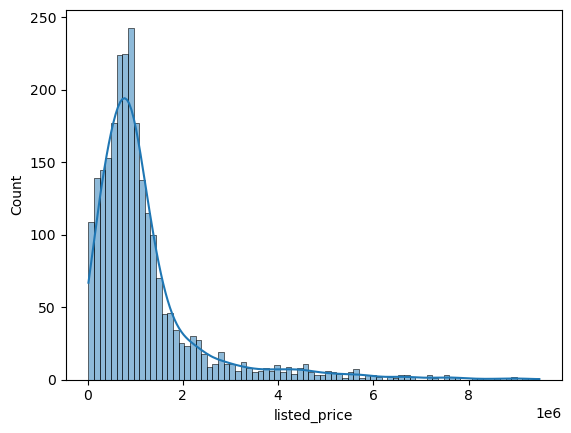

In [31]:
sns.histplot(data=df,x='listed_price',kde=True)
plt.show()

#### ESTIMATED FINAL PRICE

In [32]:
df['estimated_final_price'].unique()

array([ 819174, 1093660, 1794265, ..., 4227367,  396904,  888969])

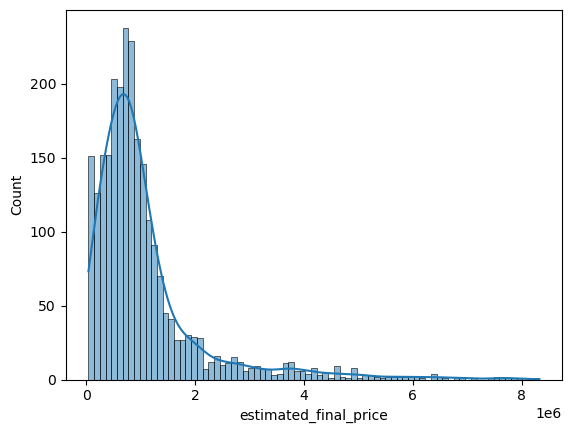

In [33]:
sns.histplot(data=df,x='estimated_final_price',kde=True)
plt.show()

#### DAYS TO SELL

In [34]:
df['days_to_sell'].unique() #Needs of cleaning

array([17., 42., 39., 26., 22., 50., 31., 62., 47., 18., 35., 34., 21.,
       77., 48., 30., 43., 36., 14., 28., 23., 27., 33., 15., 41., 20.,
       45., 37., 46., 13., 40., 25., 29., 54., 38., 65., 32., 53., 24.,
       16.,  6., 51., 70., 12., 49., 44., nan, 59., 76., 56.,  9., 19.,
       63., 55., 64., 60., 10., 71., 52.,  8., 58., 57., 66., 61., 67.,
       11., 73., 72., 80., 69., 75., 74., 68., 78.,  7.])

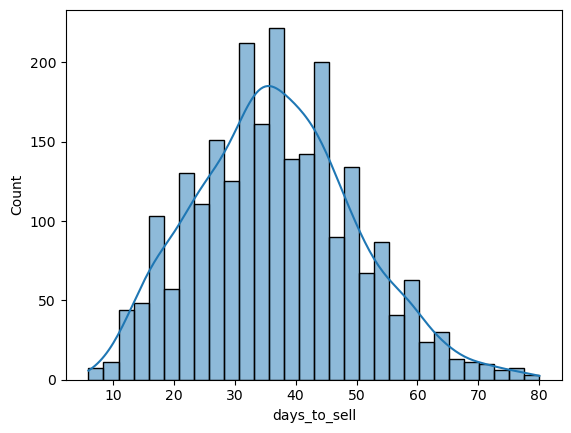

In [35]:
sns.histplot(data=df,x='days_to_sell',kde=True)
plt.show()

#### BARGAIN PERCENT

In [36]:
df['bargain_percent'].unique()

array([18, 13,  7,  6,  3,  8, 14, 16, 15,  4, 12, 11, 17,  2,  5, 19, 10,
        9, 20, 22, 23, 24, 21])

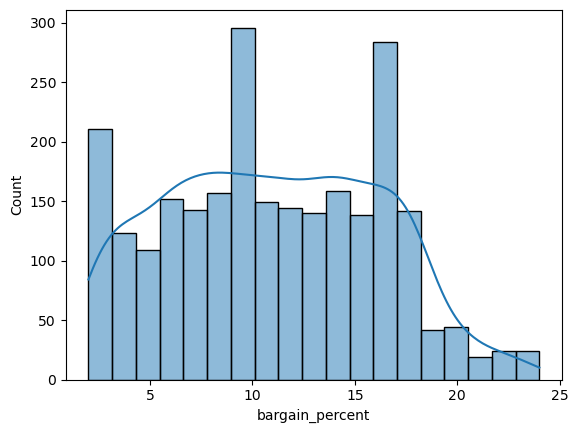

In [37]:
sns.histplot(data=df,x='bargain_percent',kde=True)
plt.show()

#### CAR AGE

In [38]:
df['car_age'].unique()

array([ 1,  2,  5,  9,  8,  7,  0, 15,  3,  4,  6, 10, 13, 12, 11, 14])

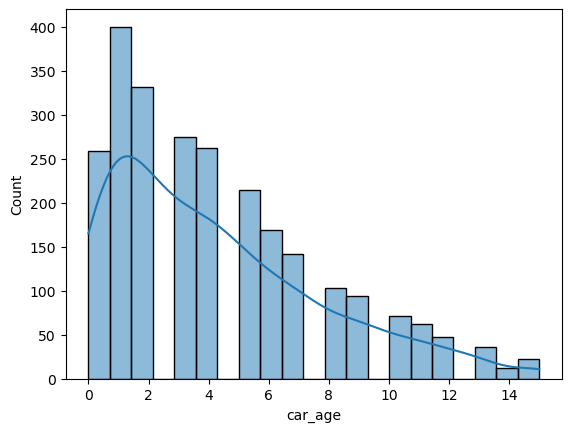

In [39]:
sns.histplot(data=df,x='car_age',kde=True)
plt.show()

#### DEPRECIATION AMOUNT

In [40]:
df['depreciation_amount'].unique()

array([ 143468,  358330,  260541, ..., 2099134, 2537657,  333785])

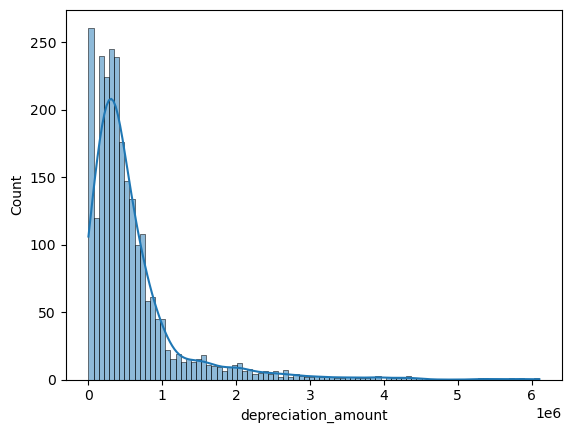

In [41]:
sns.histplot(data=df,x='depreciation_amount',kde=True)
plt.show()

#### RESALE VALUE PERCENT

In [42]:
df['resale_value_percent'].unique()

array([88.14, 79.89, 87.07, ..., 84.86, 62.16, 57.51])

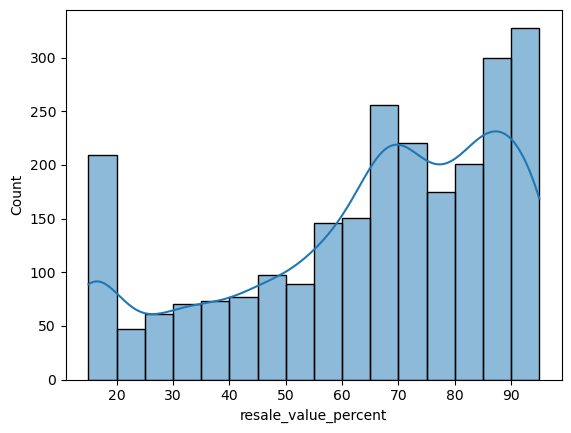

In [43]:
sns.histplot(data=df,x='resale_value_percent',kde=True)
plt.show()

#### DEMAND SCORE

In [44]:
df['demand_score'].unique()

array([ 9.19,  9.13,  9.02, 10.  ,  7.18,  5.3 ,  8.52,  5.09,  7.84,
        8.53,  7.  ,  8.95,  8.62,  3.19,  8.19,  7.63,  6.18,  5.94,
        7.98,  9.4 ,  8.83,  9.62,  6.48,  8.02,  7.75,  8.23,  7.92,
        9.42,  6.51,  7.37,  9.53,  8.91,  9.67,  9.44,  5.02,  7.22,
        8.89,  5.72,  5.05,  6.01,  9.29,  9.1 ,  8.92,  4.33,  8.74,
        6.44,  4.96,  5.19,  6.8 ,  6.06,  9.82,  8.07,  7.62,  7.94,
        7.13,  6.1 ,  7.95,  6.96,   nan,  8.31,  5.67,  8.27,  5.54,
        9.28,  8.05,  5.31,  7.66,  8.39,  7.27,  8.48,  7.59,  7.56,
        7.41,  5.88,  9.86,  8.59,  6.59,  6.82,  3.33,  7.5 ,  7.97,
        7.15,  8.47,  6.68,  6.25,  9.12,  7.65,  5.57,  8.42,  8.17,
        6.  ,  6.38,  3.  ,  5.38,  9.93,  8.68,  6.94,  9.51,  4.13,
        8.06,  7.3 ,  6.7 ,  8.21,  6.43,  5.84,  8.  ,  5.47,  4.26,
        4.02,  6.32,  8.64,  7.12,  7.99,  7.76,  7.72,  5.44,  6.16,
        7.38,  4.06,  9.61,  6.34,  6.66,  6.95,  8.99,  7.6 ,  8.08,
        8.71,  8.8 ,

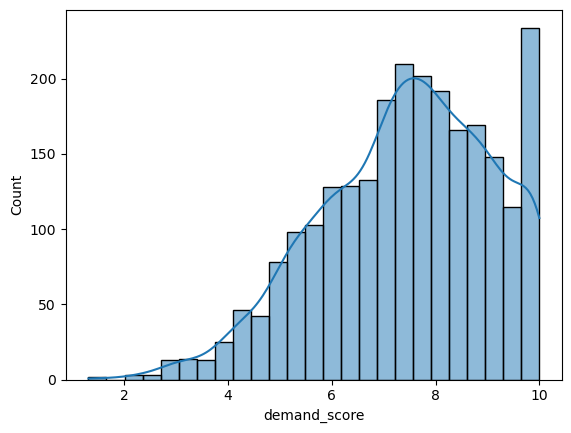

In [45]:
sns.histplot(data=df,x='demand_score',kde=True)
plt.show()

#### BRAND POPULARITY SCORE

In [46]:
df['brand_popularity_score'].unique()

array([10,  8,  4,  5,  7,  9,  6])

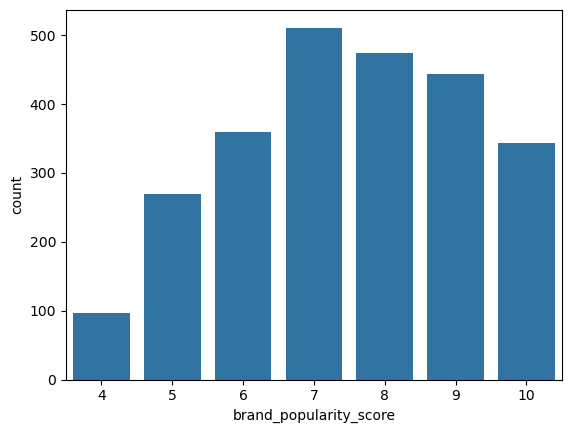

In [47]:
sns.countplot(data=df,x='brand_popularity_score')
plt.show()

#### PRICE PER KM

In [48]:
df['price_per_km'].unique()

array([  69.64,   81.31,  107.98, ..., 3028.05,   63.97, 1891.42])

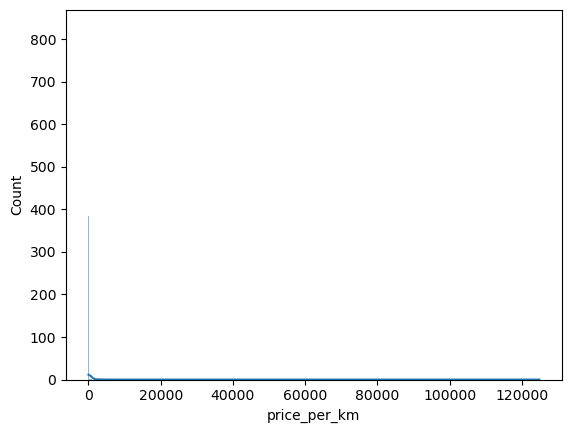

In [49]:
sns.histplot(data=df,x='price_per_km',kde=True)
plt.show()

In [50]:
df['premium_car'].unique()

array([0, 1])

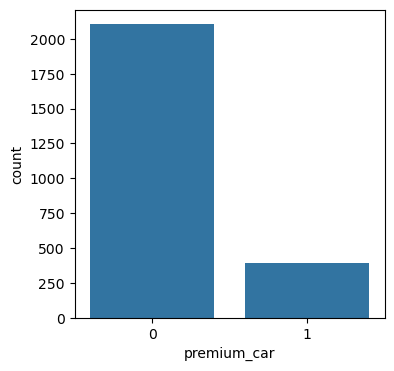

In [51]:
plt.figure(figsize=(4,4))
sns.countplot(data=df,x='premium_car')
plt.show()

## CLEANING

In [52]:
df.columns

Index(['brand', 'model', 'year', 'fuel_type', 'transmission', 'km_driven',
       'owner_type', 'city', 'mileage', 'engine_cc', 'condition_rating',
       'original_price', 'listed_price', 'estimated_final_price',
       'days_to_sell', 'bargain_percent', 'car_age', 'depreciation_amount',
       'resale_value_percent', 'demand_score', 'brand_popularity_score',
       'price_per_km', 'premium_car'],
      dtype='object')

### COLUMN THAT NEED OF CLEAING

#### FUEL TYPE

In [53]:
df['fuel_type'] = df['fuel_type'].str.strip().replace({'PETROL':'Petrol','DIESEL':'Diesel'})

#### CITY

In [54]:
df['city'] = df['city'].str.strip().replace({
        'bangalore':'Bangalore', 'hyderabad':'Hyderabad', 'chennai':'Chennai', 'lucknow':'Lucknow',
        'coimbatore':'Coimbatore', 'chandigarh':'Chandigarh', 'mumbai':'Mumbai', 'kolkata':'Kolkata',
        'delhi':'Delhi', 'surat':'Surat', 'nagpur':'Nagpur', 'jaipur':'Jaipur'})

#### MILEAGE

In [55]:
df['mileage'].unique()

array([ 20.,  21.,  16.,  14.,  15.,  22.,  18.,  25.,  17.,  24., 243.,
        19.,  27.,  26.,  nan,  30.,  28.,  23.,  13., 376.,  29.,  12.,
       342., 260.,  11.])

In [56]:
df['mileage'].isna().sum()

np.int64(51)

In [57]:
df['mileage'].fillna(df['mileage'].mean().round(),inplace=True)

In [58]:
df['mileage'].isna().any()

np.False_

#### ENGINE CC

In [59]:
df['engine_cc'].unique()

array([1199., 1493., 1999., 1462.,    0., 1197., 1497., 1461., 1498.,
        999., 1499., 1495., 1196., 1194., 1998., 1496., 2184., 2393.,
       1956., 1996., 1598., 2487., 1491., 1982., 1984.,   nan, 2755.,
        799., 1500., 1200., 1597., 1001., 1201., 1463.,  796., 2186.,
       2182., 1596.,  997., 1492., 1195., 1983., 1460., 1198., 1459.,
        797., 1464., 1995.,  998., 1997., 1193., 2183., 1958., 1192.,
       1986., 2754.,  795., 2001., 2489., 1600., 1954., 2753.])

In [60]:
df['engine_cc'].isna().sum()

np.int64(23)

In [61]:
df['engine_cc'].fillna(df.groupby(by=['year','model','fuel_type'])['engine_cc'].transform('median'),inplace=True)

In [62]:
df['engine_cc'].isna().any()

np.True_

#### DAYS TO SELL

In [63]:
df['days_to_sell'].unique()

array([17., 42., 39., 26., 22., 50., 31., 62., 47., 18., 35., 34., 21.,
       77., 48., 30., 43., 36., 14., 28., 23., 27., 33., 15., 41., 20.,
       45., 37., 46., 13., 40., 25., 29., 54., 38., 65., 32., 53., 24.,
       16.,  6., 51., 70., 12., 49., 44., nan, 59., 76., 56.,  9., 19.,
       63., 55., 64., 60., 10., 71., 52.,  8., 58., 57., 66., 61., 67.,
       11., 73., 72., 80., 69., 75., 74., 68., 78.,  7.])

In [64]:
df['days_to_sell'].isna().sum()

np.int64(51)

In [65]:
df['days_to_sell'].fillna(df['days_to_sell'].mean().round(),inplace=True)

In [66]:
df['days_to_sell'].isna().any()

np.False_

#### DEMAND SCORE

In [67]:
df['demand_score'].unique()

array([ 9.19,  9.13,  9.02, 10.  ,  7.18,  5.3 ,  8.52,  5.09,  7.84,
        8.53,  7.  ,  8.95,  8.62,  3.19,  8.19,  7.63,  6.18,  5.94,
        7.98,  9.4 ,  8.83,  9.62,  6.48,  8.02,  7.75,  8.23,  7.92,
        9.42,  6.51,  7.37,  9.53,  8.91,  9.67,  9.44,  5.02,  7.22,
        8.89,  5.72,  5.05,  6.01,  9.29,  9.1 ,  8.92,  4.33,  8.74,
        6.44,  4.96,  5.19,  6.8 ,  6.06,  9.82,  8.07,  7.62,  7.94,
        7.13,  6.1 ,  7.95,  6.96,   nan,  8.31,  5.67,  8.27,  5.54,
        9.28,  8.05,  5.31,  7.66,  8.39,  7.27,  8.48,  7.59,  7.56,
        7.41,  5.88,  9.86,  8.59,  6.59,  6.82,  3.33,  7.5 ,  7.97,
        7.15,  8.47,  6.68,  6.25,  9.12,  7.65,  5.57,  8.42,  8.17,
        6.  ,  6.38,  3.  ,  5.38,  9.93,  8.68,  6.94,  9.51,  4.13,
        8.06,  7.3 ,  6.7 ,  8.21,  6.43,  5.84,  8.  ,  5.47,  4.26,
        4.02,  6.32,  8.64,  7.12,  7.99,  7.76,  7.72,  5.44,  6.16,
        7.38,  4.06,  9.61,  6.34,  6.66,  6.95,  8.99,  7.6 ,  8.08,
        8.71,  8.8 ,

In [68]:
df['demand_score'].fillna(df['demand_score'].median(),inplace=True)

In [69]:
df['demand_score'].isna().any()

np.False_

#### PRICE PER KM

In [70]:
df['price_per_km'].unique()

array([  69.64,   81.31,  107.98, ..., 3028.05,   63.97, 1891.42])

In [71]:
df['price_per_km'].fillna(df.groupby(by='model')['price_per_km'].transform('median'),inplace=True)

In [72]:
df['price_per_km'].isna().any()

np.False_

In [73]:
df.head()

,brand,model,year,fuel_type,transmission,km_driven,owner_type,city,mileage,engine_cc,condition_rating,original_price,listed_price,estimated_final_price,days_to_sell,bargain_percent,car_age,depreciation_amount,resale_value_percent,demand_score,brand_popularity_score,price_per_km,premium_car
0,Maruti,Baleno,2024,Diesel,Automatic,14345,Second,Bhopal,20.0,1199.0,10,1133417,998993,819174,17.0,18,1,143468,88.14,9.19,10,69.64,0
1,Hyundai,Creta,2023,Petrol,Automatic,15461,First,Kolkata,21.0,1493.0,8,1573516,1257081,1093660,42.0,13,2,358330,79.89,9.13,10,81.31,0
2,Hyundai,Alcazar,2024,Petrol,Manual,17868,Third,Pune,20.0,1999.0,10,2215825,1929318,1794265,39.0,7,1,260541,87.07,9.02,10,107.98,0
3,Hyundai,Creta,2023,Petrol,Manual,21002,First,Bangalore,16.0,1493.0,10,1407825,1181587,1110691,26.0,6,2,253206,83.93,10.00,10,56.26,0
4,Tata,Tiago,2020,Petrol,Manual,59742,Second,Chandigarh,14.0,1199.0,8,671505,386921,375313,22.0,3,5,301973,57.62,7.18,8,6.48,0


In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   brand                   2500 non-null   object 
 1   model                   2500 non-null   object 
 2   year                    2500 non-null   int64  
 3   fuel_type               2500 non-null   object 
 4   transmission            2500 non-null   object 
 5   km_driven               2500 non-null   int64  
 6   owner_type              2500 non-null   object 
 7   city                    2500 non-null   object 
 8   mileage                 2500 non-null   float64
 9   engine_cc               2495 non-null   float64
 10  condition_rating        2500 non-null   int64  
 11  original_price          2500 non-null   int64  
 12  listed_price            2500 non-null   int64  
 13  estimated_final_price   2500 non-null   int64  
 14  days_to_sell            2500 non-null   

In [75]:
df.dropna(inplace=True)

In [76]:
df.isna().sum()

brand                     0
model                     0
year                      0
fuel_type                 0
transmission              0
km_driven                 0
owner_type                0
city                      0
mileage                   0
engine_cc                 0
condition_rating          0
original_price            0
listed_price              0
estimated_final_price     0
days_to_sell              0
bargain_percent           0
car_age                   0
depreciation_amount       0
resale_value_percent      0
demand_score              0
brand_popularity_score    0
price_per_km              0
premium_car               0
dtype: int64

### CHECK THE RELATION OF INPUT FEATURES WITH OUTPUT FEATURE

#### FOR NUMERICAL COLUMNS

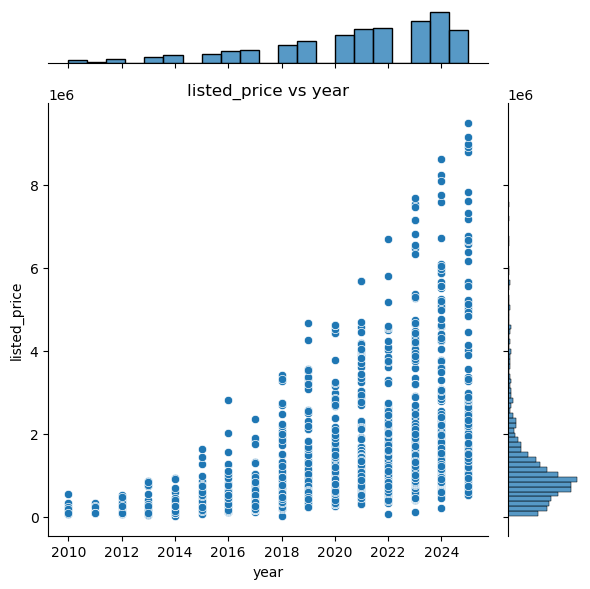

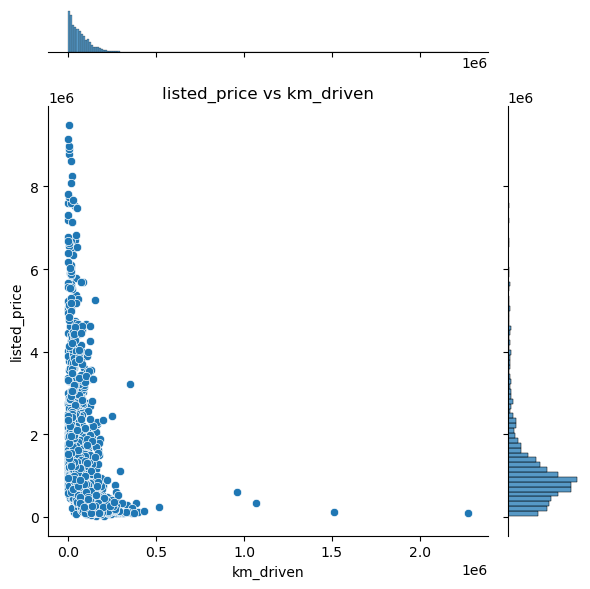

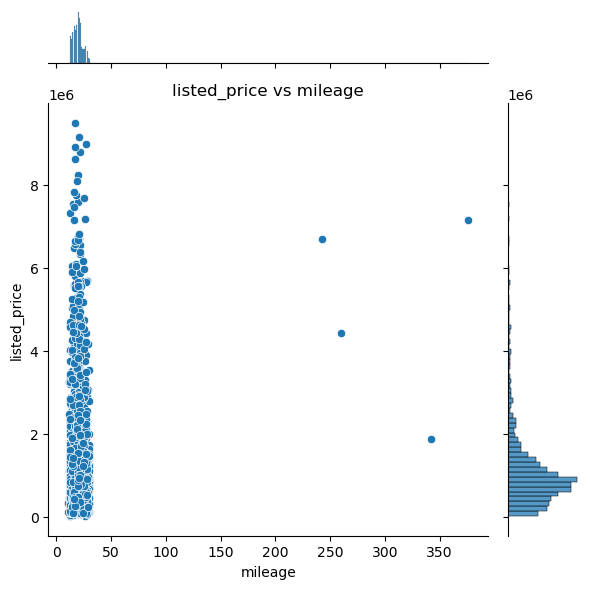

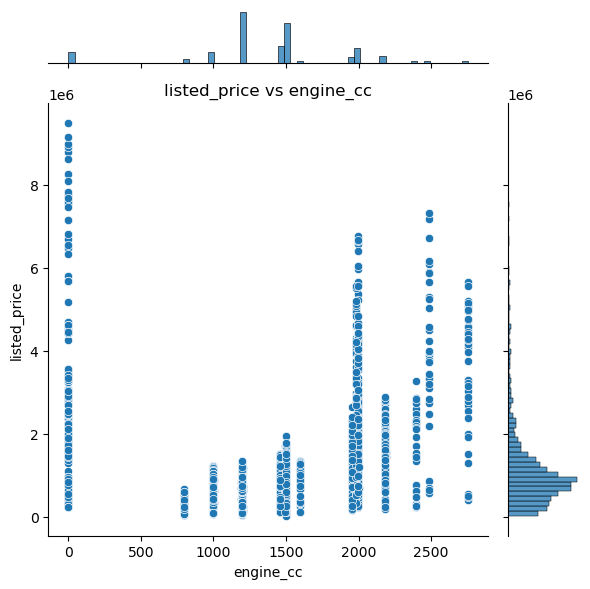

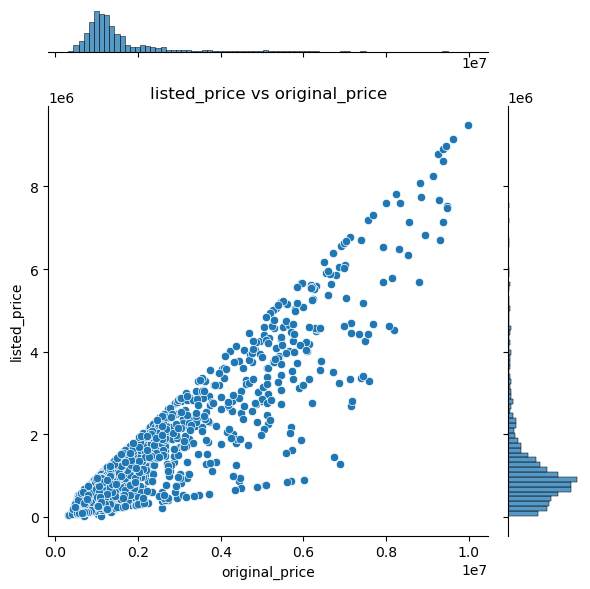

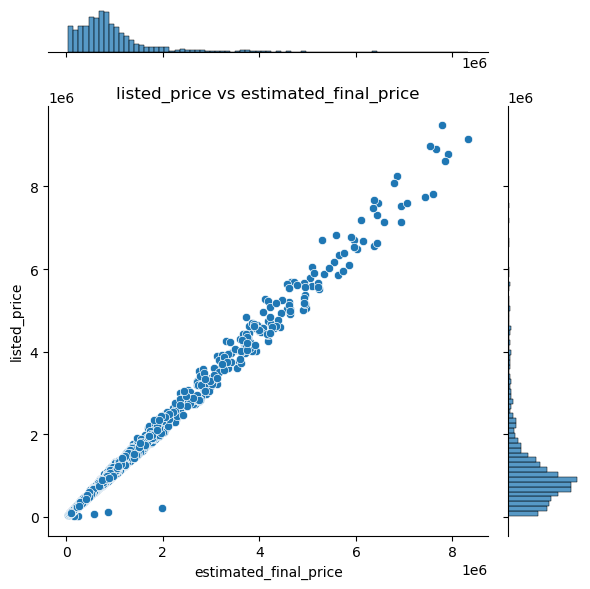

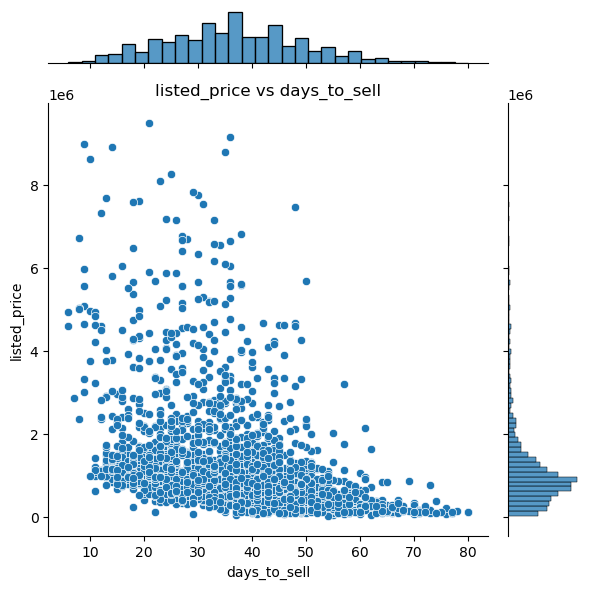

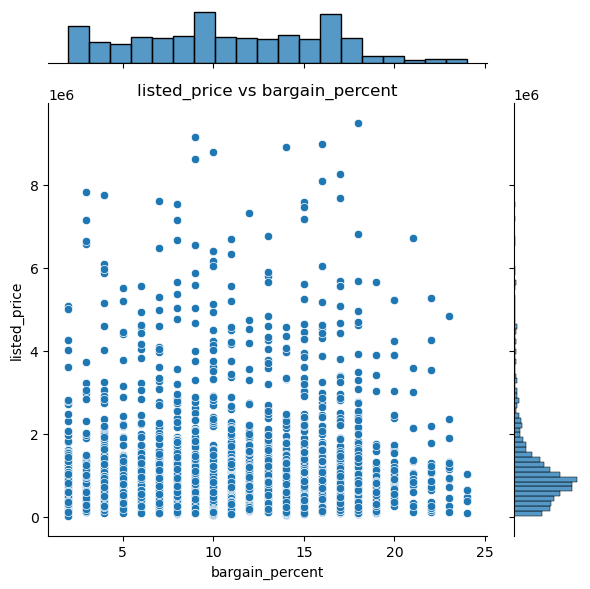

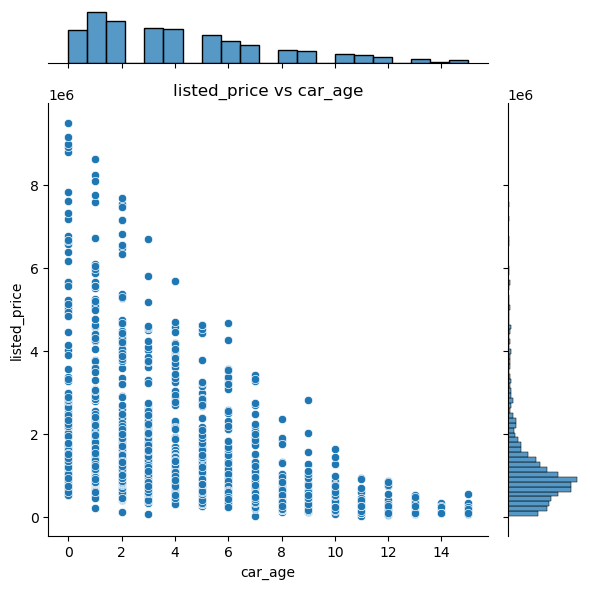

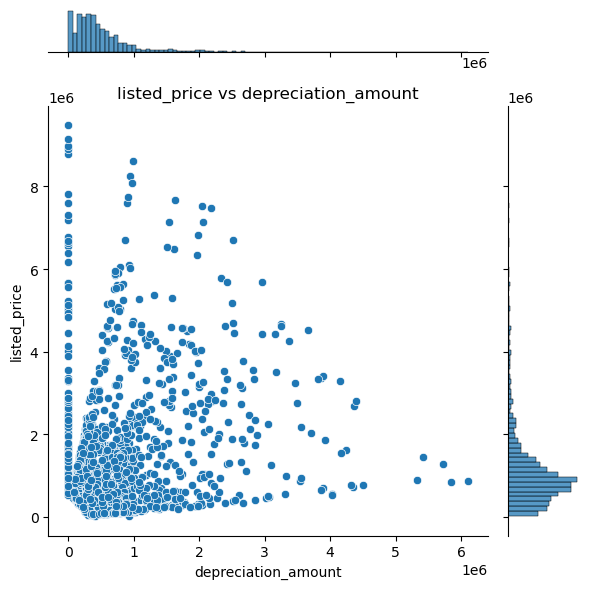

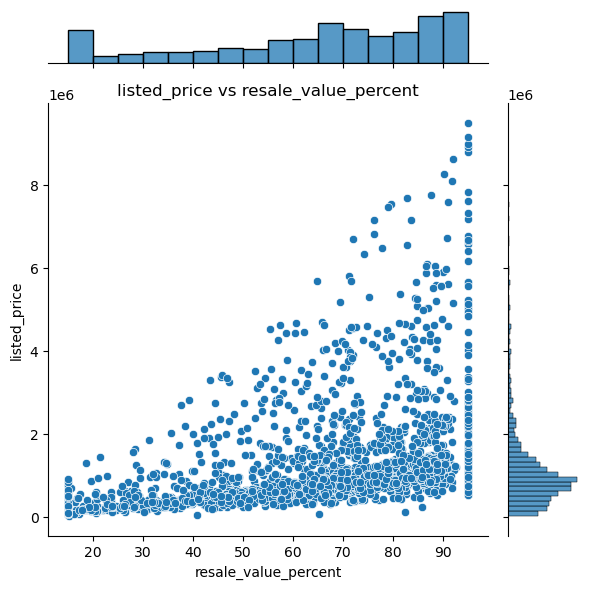

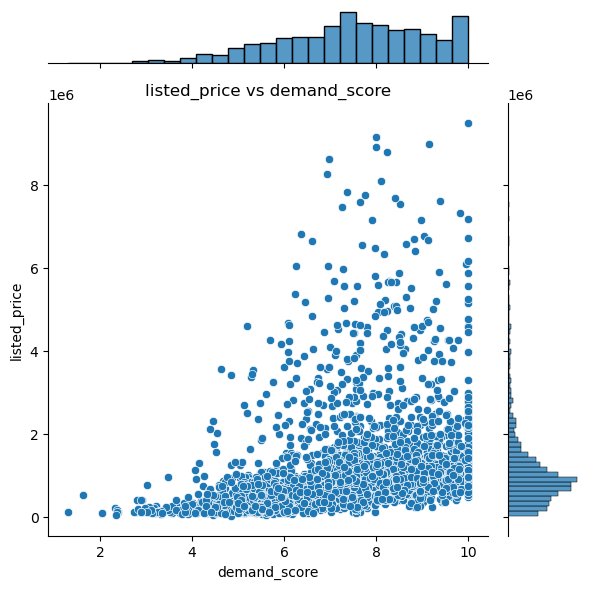

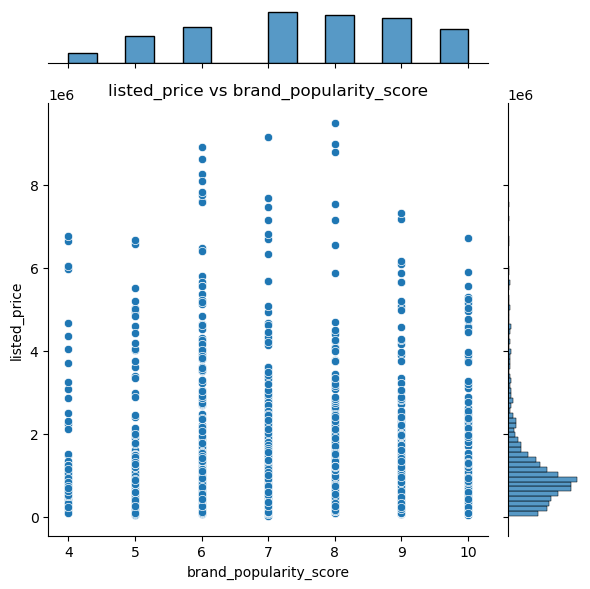

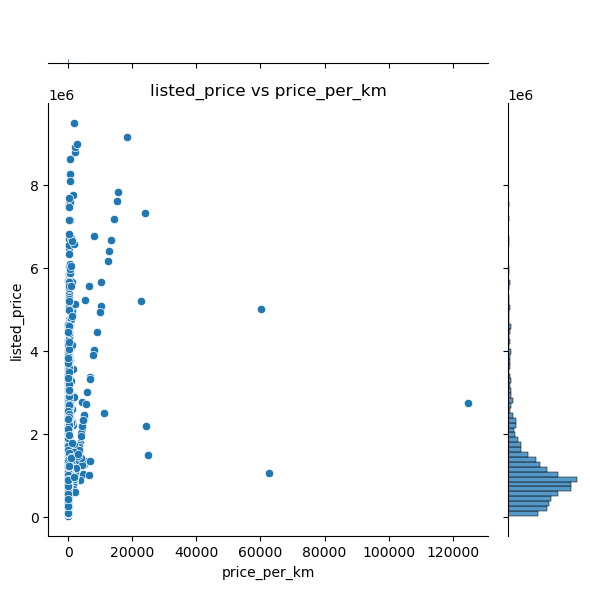

In [77]:
cols = ['year','km_driven','mileage','engine_cc','original_price',
        'estimated_final_price','days_to_sell','bargain_percent','car_age',
       'depreciation_amount','resale_value_percent','demand_score',
       'brand_popularity_score','price_per_km',]

for col in range(len(cols)):
    sns.jointplot(data=df,x=cols[col],y='listed_price')
    plt.title(f'listed_price vs {cols[col]}')
    plt.tight_layout()
    
plt.show()

#### FOR CATEGORICAL COLUMNS

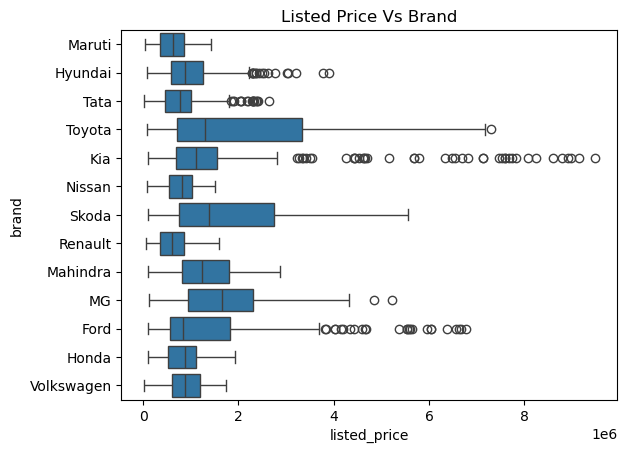

In [78]:
sns.boxplot(data=df,x='listed_price',y='brand')
plt.title("Listed Price Vs Brand")
plt.show()

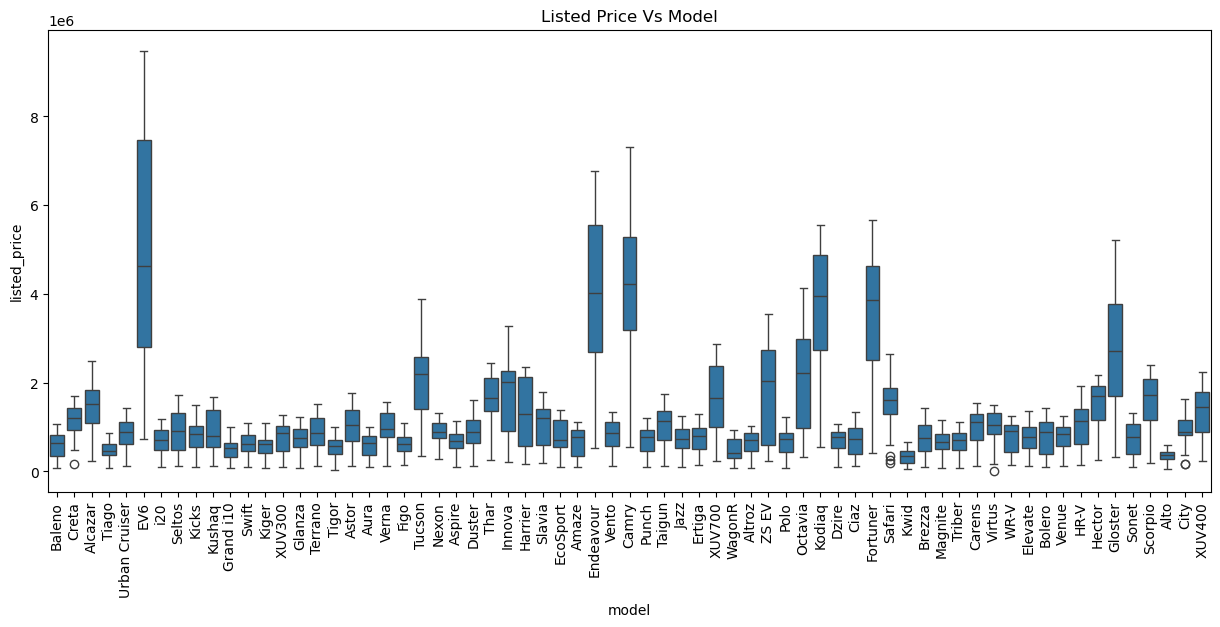

In [79]:
plt.figure(figsize=(15,6))
sns.boxplot(data=df,x='model',y='listed_price')
plt.xticks(rotation=90)
plt.title("Listed Price Vs Model")
plt.show()

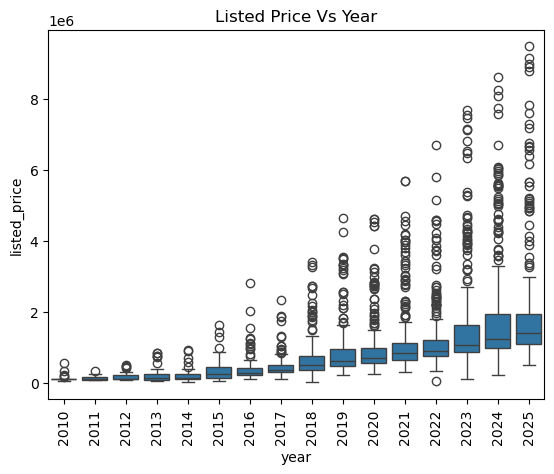

In [80]:
sns.boxplot(data=df,x='year',y='listed_price')
plt.xticks(rotation=90)
plt.title("Listed Price Vs Year")
plt.show()

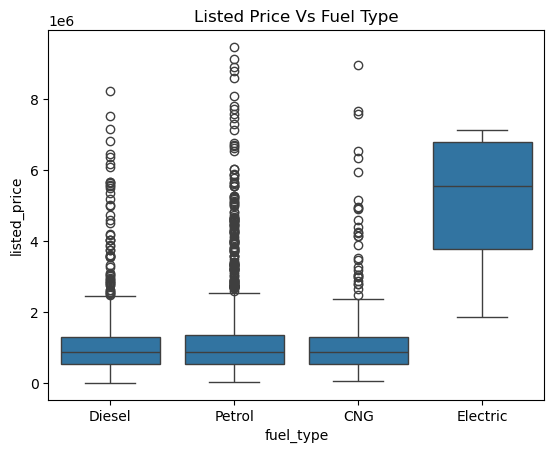

In [81]:
sns.boxplot(data=df,x='fuel_type',y='listed_price')
plt.title("Listed Price Vs Fuel Type")
plt.show()

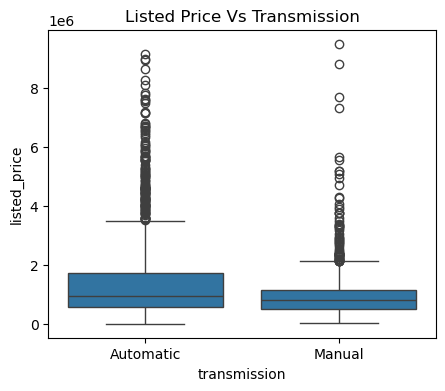

In [82]:
plt.figure(figsize=(5,4))
sns.boxplot(data=df,x='transmission',y='listed_price')
plt.title("Listed Price Vs Transmission")
plt.show()

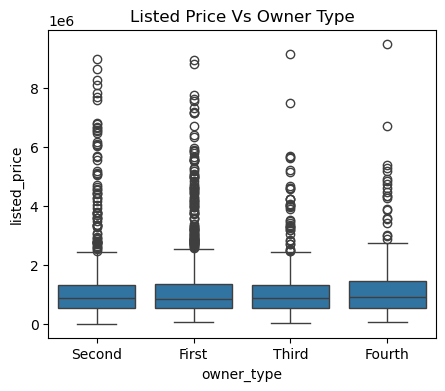

In [83]:
plt.figure(figsize=(5,4))
sns.boxplot(data=df,x='owner_type',y='listed_price')  
plt.title("Listed Price Vs Owner Type")                  
plt.show() 

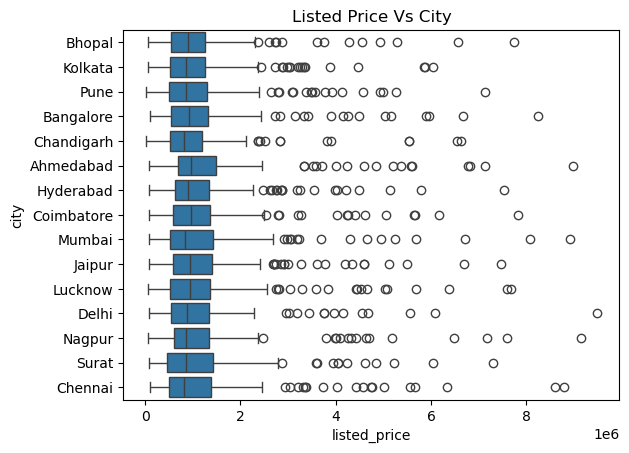

In [84]:
sns.boxplot(data=df,x='listed_price',y='city')  
plt.title("Listed Price Vs City")
plt.show()

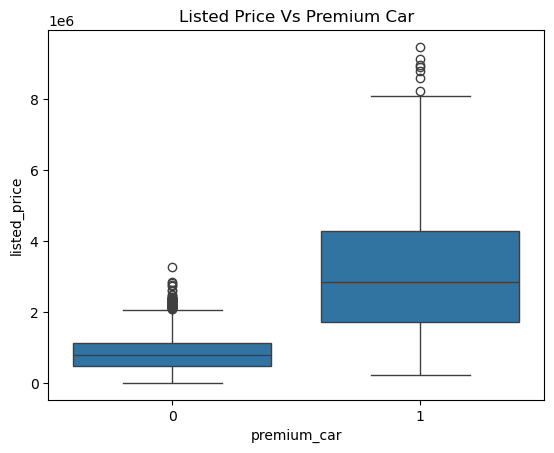

In [85]:
sns.boxplot(data=df,x='premium_car',y='listed_price')  
plt.title("Listed Price Vs Premium Car")
plt.show()

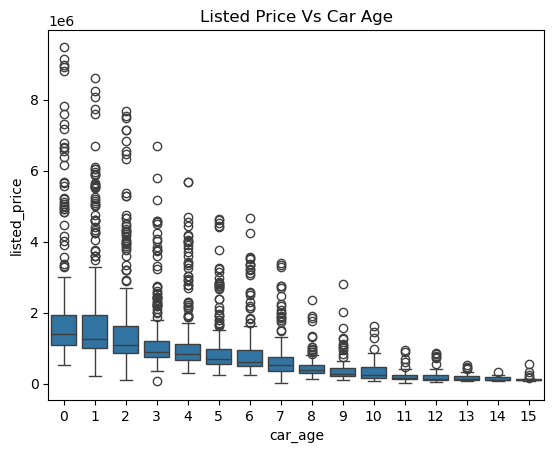

In [86]:
sns.boxplot(data=df,x='car_age',y='listed_price')  
plt.title("Listed Price Vs Car Age")
plt.show()

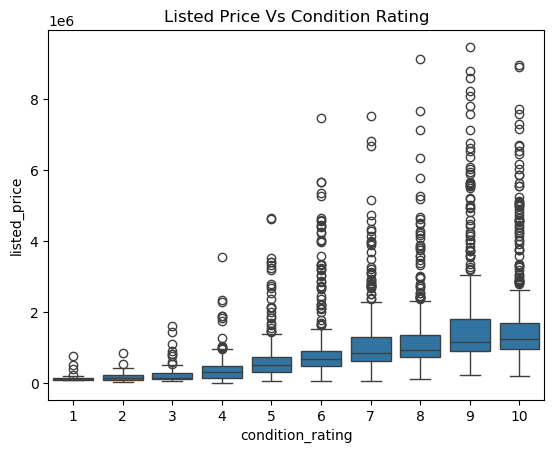

In [87]:
sns.boxplot(data=df,x='condition_rating',y='listed_price')  
plt.title("Listed Price Vs Condition Rating")
plt.show()

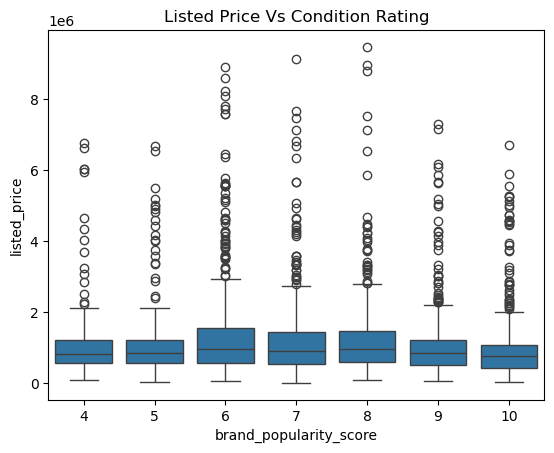

In [88]:
sns.boxplot(data=df,x='brand_popularity_score',y='listed_price')  
plt.title("Listed Price Vs Condition Rating")
plt.show()

## FEATURE ENGINEERING 

In [89]:
df['condition_per_year'] = df['condition_rating'] / (df['car_age']+1)

In [90]:
df['demand_relative_to_age'] = df['demand_score'] * df['car_age']

In [91]:
df.head()

,brand,model,year,fuel_type,transmission,km_driven,owner_type,city,mileage,engine_cc,condition_rating,original_price,listed_price,estimated_final_price,days_to_sell,bargain_percent,car_age,depreciation_amount,resale_value_percent,demand_score,brand_popularity_score,price_per_km,premium_car,condition_per_year,demand_relative_to_age
0,Maruti,Baleno,2024,Diesel,Automatic,14345,Second,Bhopal,20.0,1199.0,10,1133417,998993,819174,17.0,18,1,143468,88.14,9.19,10,69.64,0,5.000000,9.19
1,Hyundai,Creta,2023,Petrol,Automatic,15461,First,Kolkata,21.0,1493.0,8,1573516,1257081,1093660,42.0,13,2,358330,79.89,9.13,10,81.31,0,2.666667,18.26
2,Hyundai,Alcazar,2024,Petrol,Manual,17868,Third,Pune,20.0,1999.0,10,2215825,1929318,1794265,39.0,7,1,260541,87.07,9.02,10,107.98,0,5.000000,9.02
3,Hyundai,Creta,2023,Petrol,Manual,21002,First,Bangalore,16.0,1493.0,10,1407825,1181587,1110691,26.0,6,2,253206,83.93,10.00,10,56.26,0,3.333333,20.00
4,Tata,Tiago,2020,Petrol,Manual,59742,Second,Chandigarh,14.0,1199.0,8,671505,386921,375313,22.0,3,5,301973,57.62,7.18,8,6.48,0,1.333333,35.90


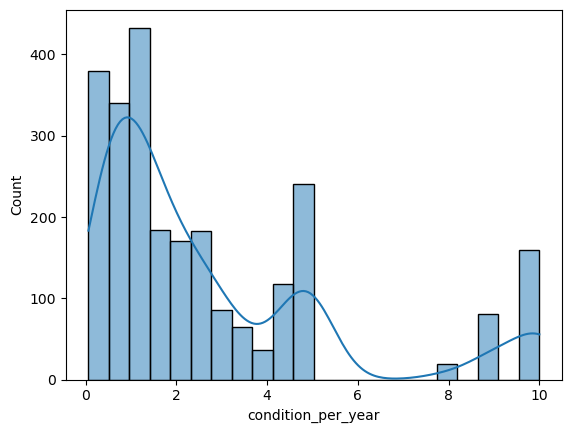

In [92]:
# =====================================================================
#             Distribution of Condition Per Year Column
# =====================================================================
sns.histplot(data=df,x='condition_per_year',kde=True)
plt.show()

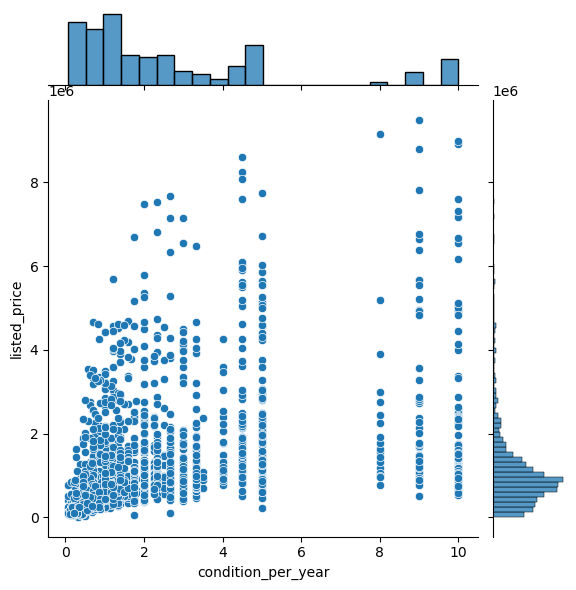

In [93]:
# =====================================================================
#                  Condition Per Year Vs Listed Price
# =====================================================================
sns.jointplot(data=df,x='condition_per_year',y='listed_price')
plt.show()

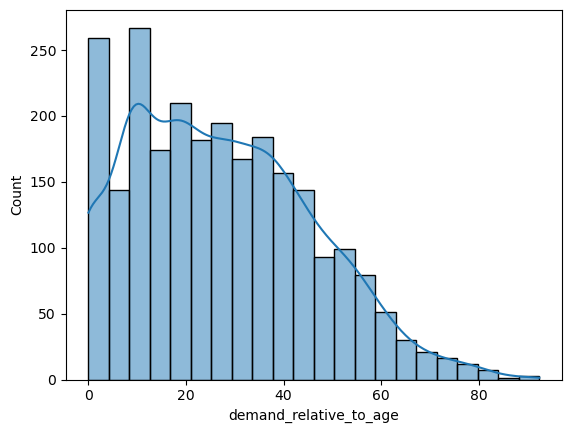

In [94]:
# =====================================================================
#             Distribution of Demand Relative To Age Column
# =====================================================================
sns.histplot(data=df,x='demand_relative_to_age',kde=True)
plt.show()

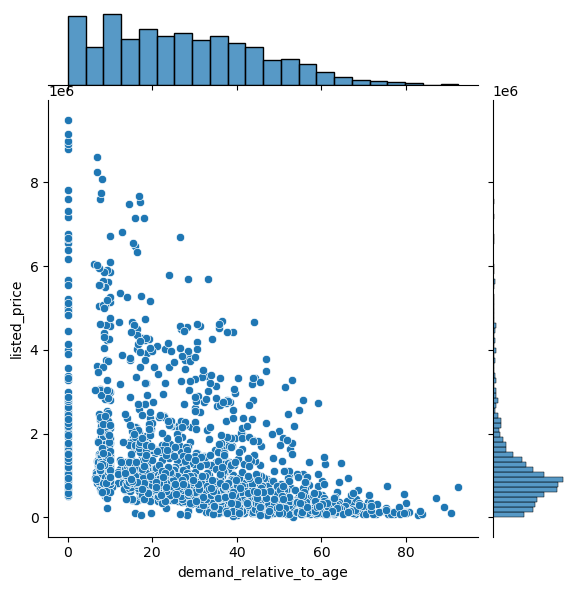

In [95]:
# =====================================================================
#               Demand Relative To Age Vs Listed Price
# =====================================================================
sns.jointplot(data=df,x='demand_relative_to_age',y='listed_price')
plt.show()

## CHECK THE CORELATION OF THE DATASET

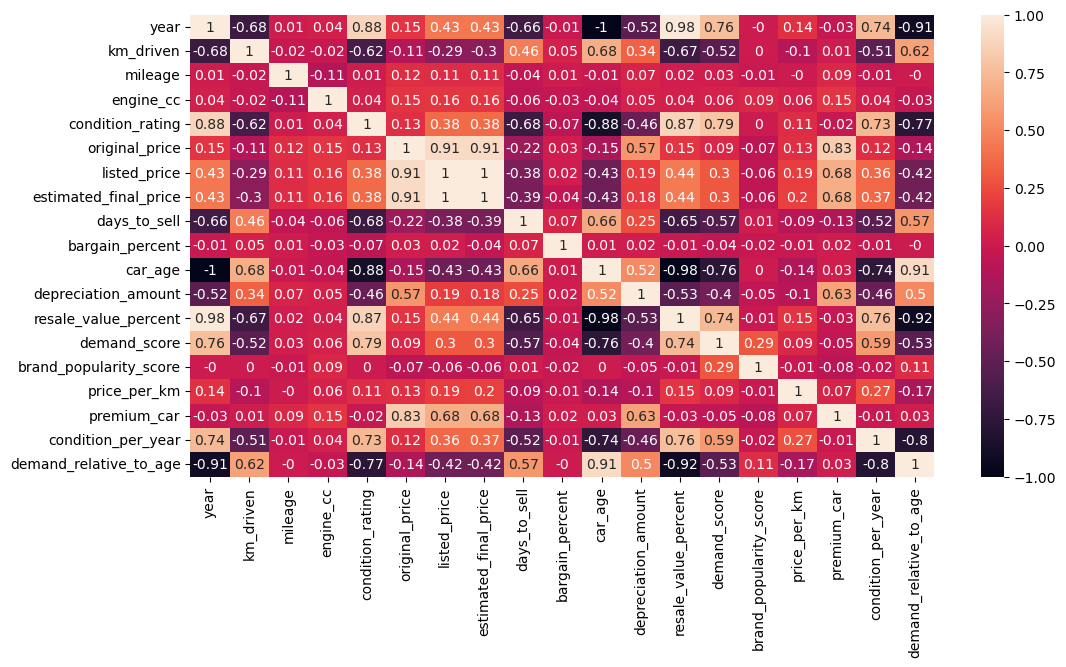

In [96]:
plt.figure(figsize=(12,6))
sns.heatmap(np.round(df.corr(numeric_only=True),2),annot=True)
plt.show()

## SPLIT INPUT-OUTPUT FEATURES

In [97]:
X = df[['brand','model','fuel_type','km_driven','car_age','premium_car','condition_per_year']]
y = df['listed_price']

## TRAIN-TEST-SPLIT

In [98]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## MAKING ML MODEL

### DEFINE YOUR COLUMN GROUPS

In [99]:
te_cols = ["brand","model"]
ohe_cols = ["fuel_type"]
num_cols = ["km_driven","car_age","premium_car","condition_per_year"]

### BUNDLE EVERYTHING INTO A COLUMN TRANSFORMER

In [100]:
from sklearn.base import clone

linear_preprocessor = ColumnTransformer(transformers=[
    ('te',  TargetEncoder(target_type="continuous", smooth="auto", random_state=42), te_cols),
    ('ohe', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False), ohe_cols),
    ('num', StandardScaler(), num_cols)
])

tree_preprocessor = ColumnTransformer(transformers=[
    ('te',  TargetEncoder(target_type="continuous", smooth="auto", random_state=42), te_cols),
    ('ohe', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False), ohe_cols),
    ('num', 'passthrough', num_cols)
])

### BUILD THE FINAL MASTER PIPELINE

In [101]:
lr_model_pipeline = Pipeline(
    steps=[
        ('preprocessor',linear_preprocessor),
        ('lr_model',LinearRegression())
    ]
)

lasso_model_pipeline = Pipeline(
    steps=[
        ('preprocessor',linear_preprocessor),
        ('lasso_model',Lasso())
    ]
)

ridge_model_pipeline = Pipeline(
    steps=[
        ('preprocessor',linear_preprocessor),
        ('ridge_model',Ridge())
    ]
)
dt_model_pipeline = Pipeline(
    steps=[
        ('preprocessor',tree_preprocessor),
        ('dt_model',DecisionTreeRegressor())
    ]
)
rf_model_pipeline = Pipeline(
    steps=[
        ('preprocessor',tree_preprocessor),
        ('rf_model',RandomForestRegressor())
    ]
)

## TRAIN THE MODEL

In [102]:
results = []
# =====================================================================
#                         LinearRegression 
# =====================================================================
lr_model_pipeline.fit(X_train, y_train)
y_prediction_lr = lr_model_pipeline.predict(X_test)
r2_score_lr = r2_score(y_test, y_prediction_lr)
rmse_lr = root_mean_squared_error(y_test, y_prediction_lr)
results.append({
    'Model': 'LinearRegression',
    'R2 Score': round(r2_score_lr, 4),
    'RMSE': round(rmse_lr, 4)
})
# =====================================================================
#                         LassoRegression 
# =====================================================================
lasso_model_pipeline.fit(X_train, y_train)
y_prediction_lasso = lasso_model_pipeline.predict(X_test)
r2_score_lasso = r2_score(y_test, y_prediction_lasso)
rmse_lasso = root_mean_squared_error(y_test, y_prediction_lasso)
results.append({
    'Model': 'LassoRegression',
    'R2 Score': round(r2_score_lasso, 4),
    'RMSE': round(rmse_lasso, 4)
})
# =====================================================================
#                         RidgeRegression 
# =====================================================================
ridge_model_pipeline.fit(X_train, y_train)
y_prediction_ridge = ridge_model_pipeline.predict(X_test)
r2_score_ridge = r2_score(y_test, y_prediction_ridge)
rmse_ridge = root_mean_squared_error(y_test, y_prediction_ridge)
results.append({
    'Model': 'RidgeRegression',
    'R2 Score': round(r2_score_ridge, 4),
    'RMSE': round(rmse_ridge, 4)
})
# =====================================================================
#                        DecisionTree Regressor
# =====================================================================
dt_model_pipeline.fit(X_train,y_train) 
y_prediction_dt = dt_model_pipeline.predict(X_test)
r2_score_dt = r2_score(y_test, y_prediction_dt)
rmse_dt = root_mean_squared_error(y_test, y_prediction_dt)
results.append({
    'Model': 'DecisionTree Regressor',
    'R2 Score': round(r2_score_dt, 4),
    'RMSE': round(rmse_dt, 4)
})
# =====================================================================
#                       RandomForest Regressor
# =====================================================================
rf_model_pipeline.fit(X_train,y_train) 
y_prediction_rf = rf_model_pipeline.predict(X_test)
r2_score_rf = r2_score(y_test, y_prediction_rf)
rmse_rf = root_mean_squared_error(y_test, y_prediction_rf)
results.append({
    'Model': 'RandomForest Regressor',
    'R2 Score': round(r2_score_rf, 4),
    'RMSE': round(rmse_rf, 4)
})

## CHECK ACCURACY

In [103]:
results

[{'Model': 'LinearRegression', 'R2 Score': 0.8522, 'RMSE': 466140.3475},
 {'Model': 'LassoRegression', 'R2 Score': 0.8522, 'RMSE': 466140.5472},
 {'Model': 'RidgeRegression', 'R2 Score': 0.8523, 'RMSE': 466063.9822},
 {'Model': 'DecisionTree Regressor', 'R2 Score': 0.953, 'RMSE': 262777.8256},
 {'Model': 'RandomForest Regressor', 'R2 Score': 0.9708, 'RMSE': 207322.4197}]

## PREDICT ON NEW RAW DATA

In [104]:
new_customers_inputs = pd.DataFrame([{
    'brand': 'Mahindra', 'model': 'XUV700', 'fuel_type': 'CNG', 'km_driven': 19600,
    'car_age': 1, 'premium_car': 1, 'condition_per_year': 5.000000
},{
    'brand': 'Mahindra', 'model': 'XUV700', 'fuel_type': 'CNG', 'km_driven': 25000,
    'car_age': 3, 'premium_car': 1, 'condition_per_year': 4.500000
}])

prediction = rf_model_pipeline.predict(new_customers_inputs)
print(f"Prediction for new data: {prediction}")

Prediction for new data: [2522701.58 2303415.53]


## HYPERPARAMETER TUNE THE MODEL

In [105]:
tuned_results = []
# =====================================================================
#                     ---TUNE THE LASSO MDDEL---
# =====================================================================
param_grid_lasso = {'lasso_model__alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]}
gslasso_model = GridSearchCV(estimator=lasso_model_pipeline, param_grid=param_grid_lasso, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
gslasso_model.fit(X_train, y_train)
# ---PRIDECT THE TUNE LASSO MODEL---
y_prediction_gslasso = gslasso_model.predict(X_test)
# print(f"Best Alpha for Lasso: {gsridge_model.best_params_['alpha']}")
print(f"Best Params for Lasso: {gslasso_model.best_params_}")
print(f"Best Score for Lasso: {gslasso_model.best_score_}")
# ---CHECK THE ACCURACY OF TUNE LASSO MODEL---
r2_score_gslasso = r2_score(y_test, y_prediction_gslasso)
rmse_gslasso = root_mean_squared_error(y_test, y_prediction_gslasso)
tuned_results.append({
    'Model': 'Losso_Tuned',
    'Optimized Lasso R²': round(r2_score_gslasso,4),
    'Optimized Lasso RMSE': round(rmse_gslasso,4)
})
print("="*130)
# =====================================================================
#                     ---TUNE THE RIDGE MODEL---
# =====================================================================
param_grid_ridge = {'ridge_model__alpha': [0.0001, 0.001, 0.01, 0.1, 1.0]}
gsridge_model = GridSearchCV(estimator=ridge_model_pipeline, param_grid=param_grid_ridge, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
gsridge_model.fit(X_train, y_train)
# ---PRIDECT THE TUNE Ridge MODEL---
y_prediction_gsridge = gsridge_model.predict(X_test)
# print(f"Best Alpha for Ridge: {gsridge_model.best_params_['alpha']}")
print(f"Best Params for Ridge: {gsridge_model.best_params_}")
print(f"Best Score for Ridge: {gsridge_model.best_score_}")
# ---CHECK THE ACCURACY OF TUNE RIDGE MODEL---
r2_score_gsridge = r2_score(y_test, y_prediction_gsridge)
rmse_gsridge = root_mean_squared_error(y_test, y_prediction_gsridge)
tuned_results.append({
    'Model': 'Ridge_Tuned',
    'Optimized Ridge R²': round(r2_score_gsridge,4),
    'Optimized Ridge RMSE': round(rmse_gsridge,4)
})
print('='*130)
# =====================================================================
#             ---TUNE THE DECISION-TREE REGRESSOR MODEL---
# =====================================================================
param_grid_dt= {
    'dt_model__criterion': ['squared_error', 'friedman_mse', 'absolute_error'],
    'dt_model__max_depth': [None, 3, 5, 10, 15, 20],
    'dt_model__max_features': [None, 'sqrt', 'log2', 0]
}
gsdt_model = GridSearchCV(estimator=dt_model_pipeline,param_grid=param_grid_dt,cv=5,scoring='neg_mean_squared_error',n_jobs=-1)
gsdt_model.fit(X_train,y_train)
# ---PRIDECT THE TUNE DECISION-TREE MODEL---
y_prediction_gsdt = gsdt_model.predict(X_test)
print(f"Best Params for DecisionTree: {gsdt_model.best_params_}")
print(f"Best Score for DecisionTree: {gsdt_model.best_score_}")
# ---CHECK THE ACCURACY OF TUNE DECISION-TREE MODEL---
r2_score_gsdt = r2_score(y_test, y_prediction_gsdt)
rmse_gsdt = root_mean_squared_error(y_test, y_prediction_gsdt)
tuned_results.append({
    'Model': 'DecisionTree_Tuned',
    'Optimized dt R²': round(r2_score_gsdt,4),
    'Optimized dt RMSE': round(rmse_gsdt,4)
})
print('='*130)
# =====================================================================
#            ---TUNE THE RANDOM-FORESET REGRESSOR MODEL---
# =====================================================================
param_grid_rf = {
    'rf_model__n_estimators':[100,300,500],
    'rf_model__max_depth': [None, 20, 30], 
    'rf_model__min_samples_split':[2,4,6],
    'rf_model__max_features': [1.0, 'sqrt'] 
}
# Run a randomized sweep over 15 random combinations instead of testing all 54 in Grid
rsrf_model = RandomizedSearchCV(
    estimator=rf_model_pipeline,
    param_distributions=param_grid_rf,
    n_iter=15, 
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    random_state=42
)

rsrf_model.fit(X_train, y_train)
# ---PRIDECT THE TUNE RANDOM-FOREST MODEL---
y_prediction_rsrf = rsrf_model.predict(X_test)
print(f"Best Params for RandomForest: {rsrf_model.best_params_}")
print(f"Best Score for RandomForest: {rsrf_model.best_score_}")
# ---CHECK THE ACCURACY OF TUNE RANDOM-FOREST MODEL---
r2_score_rsrf = r2_score(y_test, y_prediction_rsrf)
rmse_rsrf = root_mean_squared_error(y_test, y_prediction_rsrf)
tuned_results.append({
    'Model': 'RandomForest_Tuned',
    'Optimized RandomForest R²': round(r2_score_rsrf,4),
    'Optimized RandomForest RMSE': round(rmse_rsrf,4)
})

Best Params for Lasso: {'lasso_model__alpha': 100.0}
Best Score for Lasso: -280728861736.6471
Best Params for Ridge: {'ridge_model__alpha': 1.0}
Best Score for Ridge: -279999349561.6279
Best Params for DecisionTree: {'dt_model__criterion': 'absolute_error', 'dt_model__max_depth': 10, 'dt_model__max_features': None}
Best Score for DecisionTree: -95599779922.48091
Best Params for RandomForest: {'rf_model__n_estimators': 500, 'rf_model__min_samples_split': 6, 'rf_model__max_features': 1.0, 'rf_model__max_depth': 30}
Best Score for RandomForest: -52616648955.58222


### CHECK THE ACCURACY OF TUNED MODEL

In [106]:
tuned_results

[{'Model': 'Losso_Tuned',
  'Optimized Lasso R²': 0.8522,
  'Optimized Lasso RMSE': 466160.676},
 {'Model': 'Ridge_Tuned',
  'Optimized Ridge R²': 0.8523,
  'Optimized Ridge RMSE': 466063.9822},
 {'Model': 'DecisionTree_Tuned',
  'Optimized dt R²': 0.944,
  'Optimized dt RMSE': 286865.2159},
 {'Model': 'RandomForest_Tuned',
  'Optimized RandomForest R²': 0.9716,
  'Optimized RandomForest RMSE': 204381.9509}]

### Extract the absolute best pipeline configuration found

In [108]:
print(f"Optimal Hyperparameters: {rsrf_model.best_params_}")
print(f"Score of Optimal Hyperparameters: {rsrf_model.best_score_}")
best_model = rsrf_model.best_estimator_
# gsridge_df = pd.DataFrame(gsridge_model.cv_results_)
# gsridge_df.columns
# gsridge_df[['param_regressor__bootstrap', 'param_regressor__max_depth','param_regressor__max_features',
         # 'param_regressor__n_estimators','mean_test_score','rank_test_score']]

Optimal Hyperparameters: {'rf_model__n_estimators': 500, 'rf_model__min_samples_split': 6, 'rf_model__max_features': 1.0, 'rf_model__max_depth': 30}
Score of Optimal Hyperparameters: -52616648955.58222


### EXPORT THE SAVED MODEL FILE

In [109]:
# =====================================================================
#                    EXPORT THE SAVED MODEL FILE
# =====================================================================
model_filename = "final_random_forest_model.pkl"
joblib.dump(best_model, model_filename)
print(f"\nSuccess! Saved deployment-ready model to: '{model_filename}'")



Success! Saved deployment-ready model to: 'final_random_forest_model.pkl'


### GENERATE DIAGNOSTIC VISUALIZATION

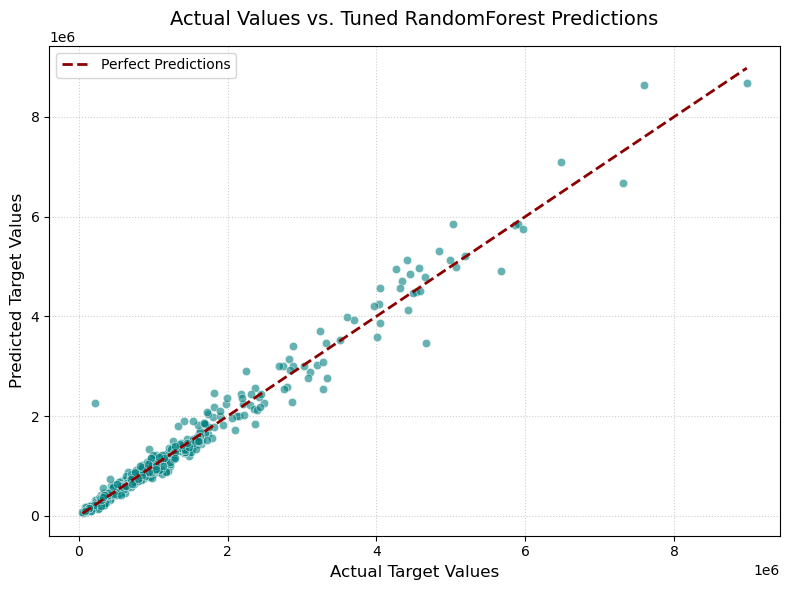

In [110]:
# =====================================================================
#           Actual Values Vs Tuned RandomForest Predictions
# =====================================================================
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_prediction_rsrf, alpha=0.6, color='teal', edgecolor='w')

# Ideal diagonal prediction line
min_val = min(y_test.min(), y_prediction_rsrf.min())
max_val = max(y_test.max(), y_prediction_rsrf.max())
plt.plot([min_val, max_val], [min_val, max_val], color='darkred', linestyle='--', linewidth=2, label='Perfect Predictions')

plt.title('Actual Values vs. Tuned RandomForest Predictions', fontsize=14, pad=15)
plt.xlabel('Actual Target Values', fontsize=12)
plt.ylabel('Predicted Target Values', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

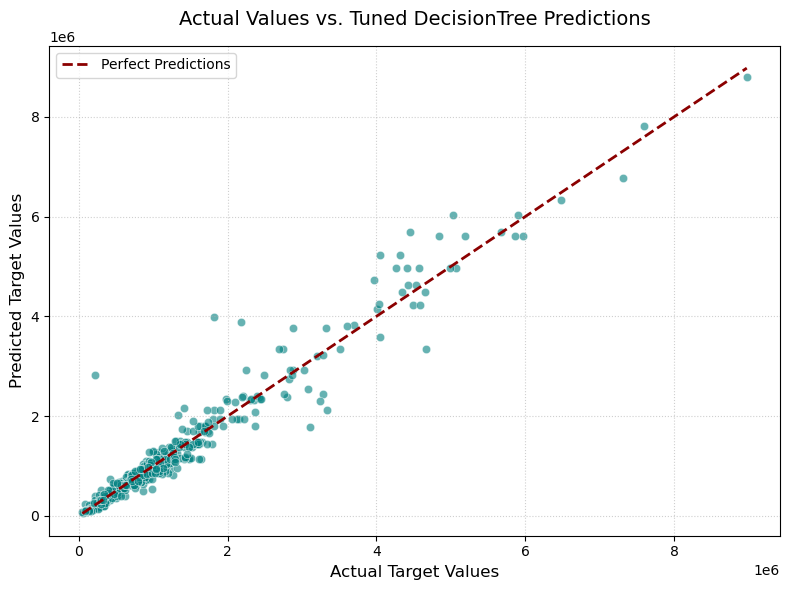

In [111]:
# =====================================================================
#           Actual Values Vs Tuned DecisionTree Predictions
# =====================================================================
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_prediction_gsdt, alpha=0.6, color='teal', edgecolor='w')

# Ideal diagonal prediction line
min_val = min(y_test.min(), y_prediction_gsdt.min())
max_val = max(y_test.max(), y_prediction_gsdt.max())
plt.plot([min_val, max_val], [min_val, max_val], color='darkred', linestyle='--', linewidth=2, label='Perfect Predictions')

plt.title('Actual Values vs. Tuned DecisionTree Predictions', fontsize=14, pad=15)
plt.xlabel('Actual Target Values', fontsize=12)
plt.ylabel('Predicted Target Values', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

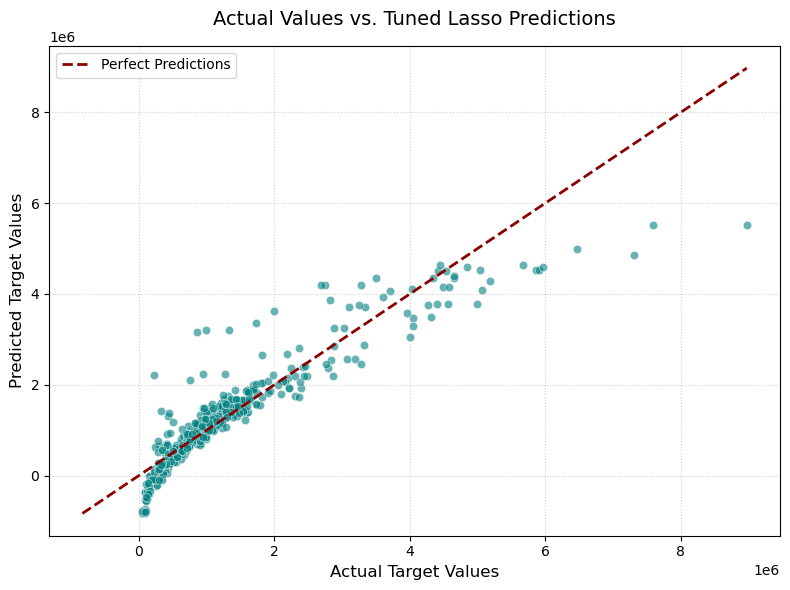

In [112]:
# =====================================================================
#              Actual Values Vs Tuned Lasso Predictions
# =====================================================================
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_prediction_gslasso, alpha=0.6, color='teal', edgecolor='w')

# Ideal diagonal prediction line
min_val = min(y_test.min(), y_prediction_gslasso.min())
max_val = max(y_test.max(), y_prediction_gslasso.max())
plt.plot([min_val, max_val], [min_val, max_val], color='darkred', linestyle='--', linewidth=2, label='Perfect Predictions')

plt.title('Actual Values vs. Tuned Lasso Predictions', fontsize=14, pad=15)
plt.xlabel('Actual Target Values', fontsize=12)
plt.ylabel('Predicted Target Values', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

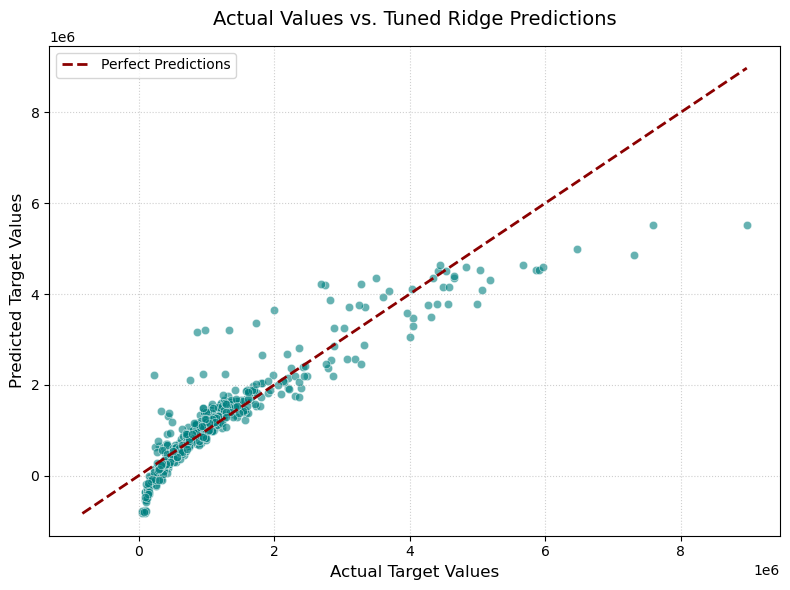

In [113]:
# =====================================================================
#            Actual Values Vs Tuned Ridge Predictions
# =====================================================================
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_prediction_gsridge, alpha=0.6, color='teal', edgecolor='w')

# Ideal diagonal prediction line
min_val = min(y_test.min(), y_prediction_gsridge.min())
max_val = max(y_test.max(), y_prediction_gsridge.max())
plt.plot([min_val, max_val], [min_val, max_val], color='darkred', linestyle='--', linewidth=2, label='Perfect Predictions')

plt.title('Actual Values vs. Tuned Ridge Predictions', fontsize=14, pad=15)
plt.xlabel('Actual Target Values', fontsize=12)
plt.ylabel('Predicted Target Values', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


### HOW TO LOAD AND RUN ON UNSEEN DATA

In [114]:
# =====================================================================
#                  HOW TO LOAD AND RUN ON UNSEEN DATA
# =====================================================================
# To make future predictions using this file in another script:

# 1. Load the production-ready file
loaded_model = joblib.load("final_random_forest_model.pkl")

# 2. NOTE: condition_per_year is a derived feature — compute it before predicting:
#    condition_per_year = condition_rating / (car_age + 1)
#    e.g. condition_rating=5, car_age=0  → 5 / (0+1) = 5.0
#         condition_rating=9, car_age=3  → 9 / (3+1) = 2.25


# 3. Gather raw, fresh data (Must have the exact same original columns as X)
new_data = pd.DataFrame(
    [{
    'brand': 'Mahindra', 'model': 'XUV700', 'fuel_type': 'CNG', 'km_driven': 19600,
    'car_age': 1, 'premium_car': 1, 'condition_per_year': 5.000000
},{
    'brand': 'Mahindra', 'model': 'XUV700', 'fuel_type': 'CNG', 'km_driven': 25000,
    'car_age': 3, 'premium_car': 1, 'condition_per_year': 4.500000
}]
)

# 4. Generate instant predictions (The model pipeline handles scaling/encoding internally)
predictions = loaded_model.predict(new_data)
print(predictions)

[2588755.43168225 2344134.93964619]
